# 🚗 Car Price Prediction

In [2]:
# =======================
# 1. Import Libraries
# =======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools

from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [3]:
# =======================
# 2. Load Dataset
# =======================

df = pd.read_csv("car data.csv")
df.head(6)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0


In [4]:
# =======================
# 3. Data Exploration
# =======================

# check missing valuses
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [5]:
df.info()   # Data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()     # Summary statistics

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
# Remove duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [9]:
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (299, 9)


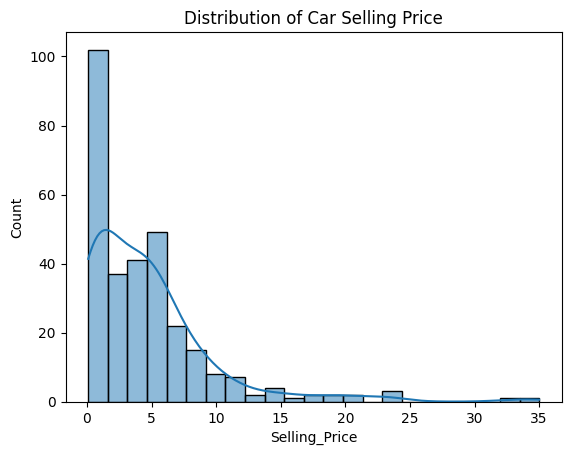

In [10]:

# =======================
# 4. Data Visualization
# =======================

sns.histplot(df['Selling_Price'], kde=True)
plt.title("Distribution of Car Selling Price")
plt.show()


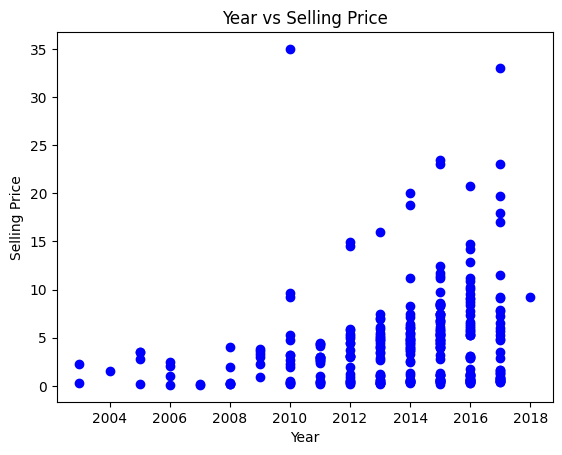

In [11]:

# =======================
# 4. Data Visualization
# =======================

plt.scatter(df['Year'], df['Selling_Price'], c ="blue")
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")

plt.show()

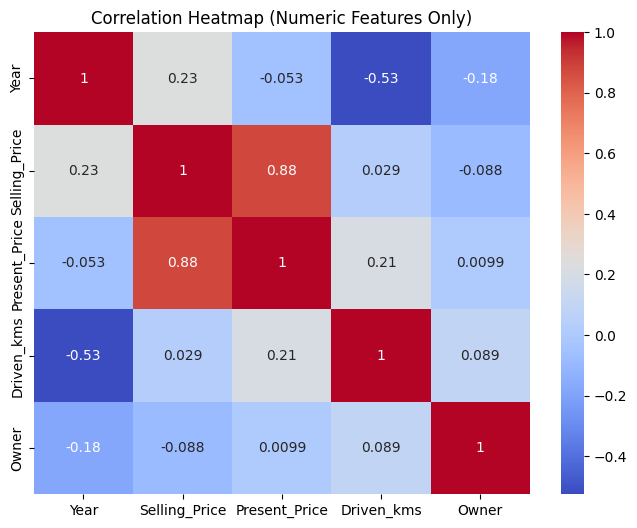

In [12]:
# =======================
# 4. Data Visualization
# =======================

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [13]:
# =======================
# 5. Feature / Target Split
# =======================

x = df.drop(['Selling_Price'], axis=1)
y = df['Selling_Price']

In [14]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


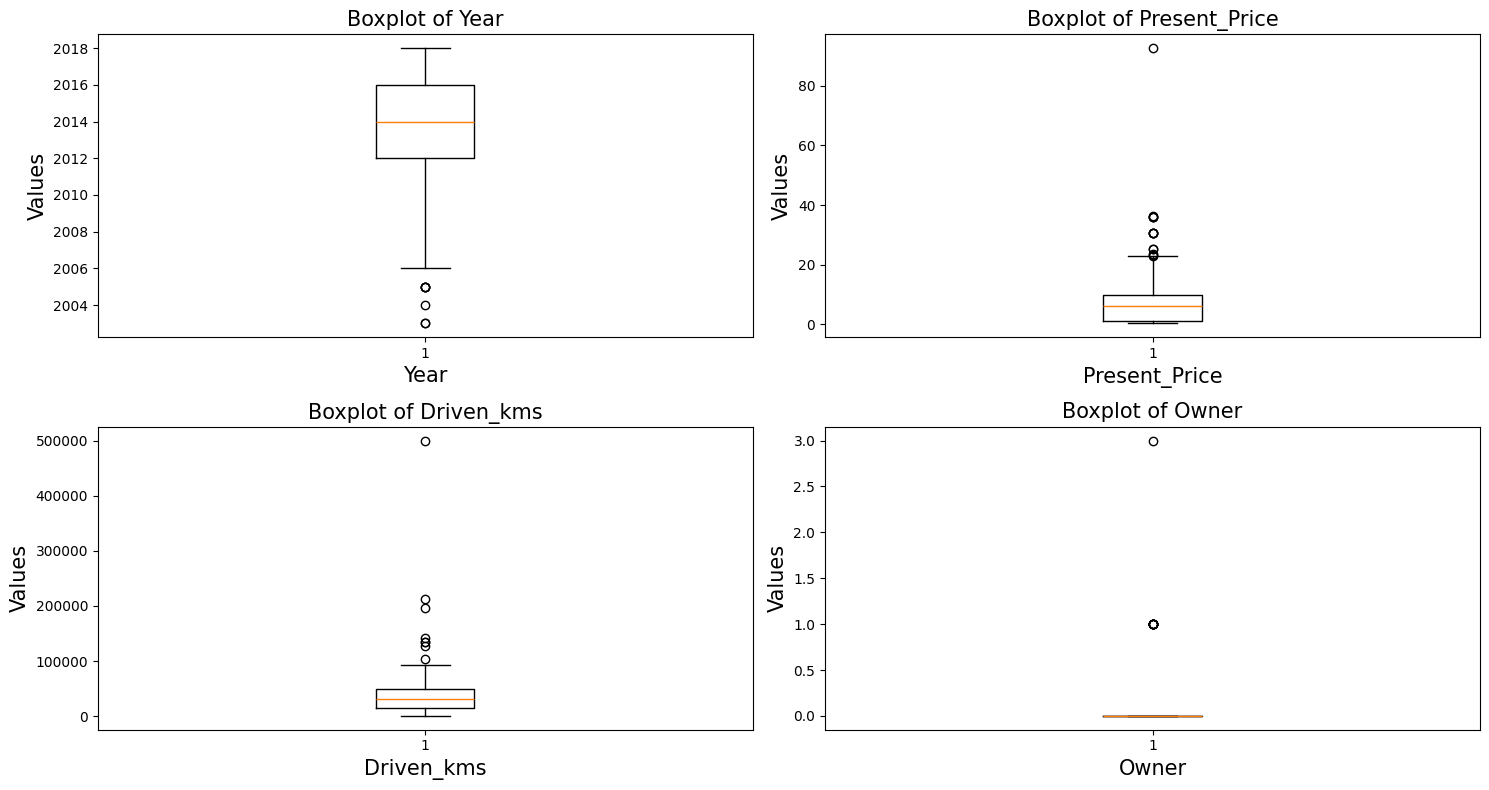

In [15]:

# =======================
# 6. Outlier Detection (IQR Method)
# =======================

num_cols = ["Year", "Present_Price", "Driven_kms", "Owner"]

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):   # i = subplot index
    plt.subplot(2, 2, i)
    plt.boxplot(x[col], vert=True)      # one boxplot per feature
    plt.title(f"Boxplot of {col}", fontsize=15)
    plt.xlabel(col, fontsize=15)
    plt.ylabel("Values", fontsize=15)

plt.tight_layout()
plt.show()


In [16]:
# Select numeric dataframe using the column list
num_df = df[["Year", "Present_Price", "Driven_kms", "Owner"]]

# Calculate IQR
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n\nLower bound:\n", lower_bound)
print("\n\nUpper bound:\n", upper_bound)



Lower bound:
 Year              2006.00
Present_Price      -11.76
Driven_kms      -35825.25
Owner                0.00
dtype: float64


Upper bound:
 Year              2022.00
Present_Price       22.80
Driven_kms       99708.75
Owner                0.00
dtype: float64


In [17]:
outlier_mask = (num_df < lower_bound) | (num_df > upper_bound)

remove_all = df[outlier_mask.any(axis=1)]
print("\n\nOutliers detected:", remove_all.shape)

remove_all.head(4)




Outliers detected: (33, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
37,800,2003,0.35,2.28,127000,Petrol,Individual,Manual,0
39,sx4,2003,2.25,7.98,62000,Petrol,Dealer,Manual,0
50,fortuner,2012,14.90,30.61,104707,Diesel,Dealer,Automatic,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [18]:
remove_all.shape

(33, 9)

In [19]:
# Remove outliers
df_clean = df.drop(index=remove_all.index)
df_clean.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [20]:
df_clean.shape

(266, 9)

In [21]:
# =======================
# 7. Feature Engineering
# =======================

df_clean['Brand'] = df_clean['Car_Name'].apply(lambda x: x.split(' ')[0].lower())
df_clean['Car_Age'] = 2025 - df_clean['Year']
df_clean.drop(['Car_Name','Year'], axis=1, inplace=True)

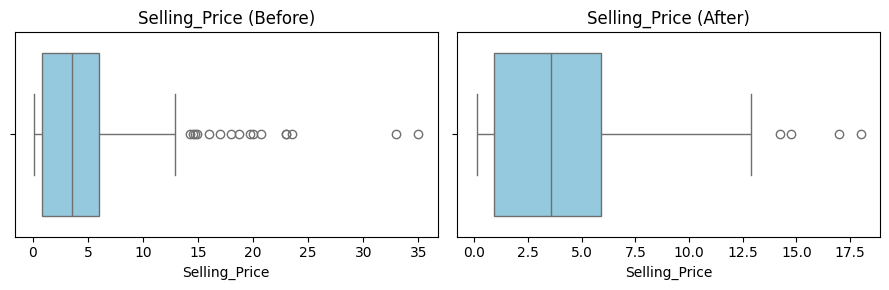

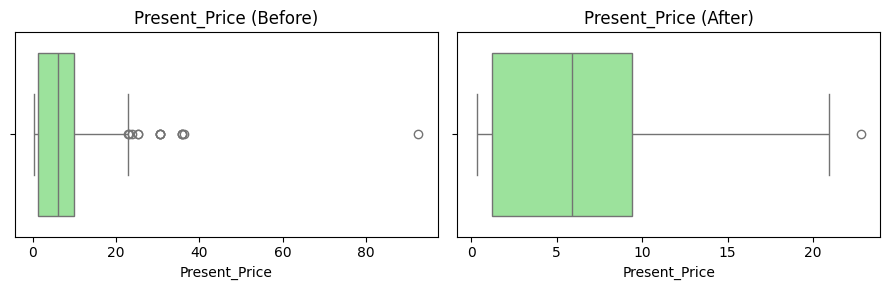

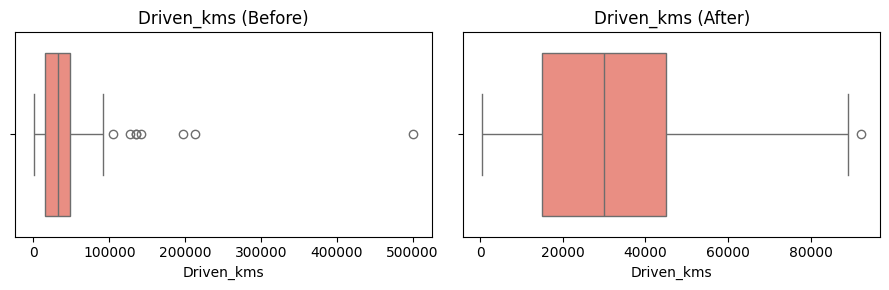

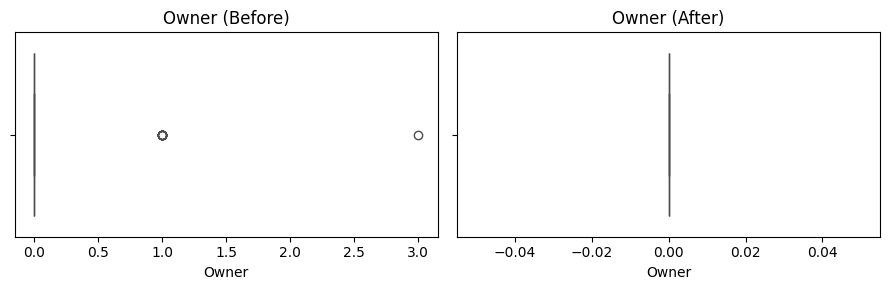

In [22]:
# =======================
# 8. befor boxplot after boxplot
# =======================

num_cols = df.select_dtypes(include=['int64','float64']).columns
clean_num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

common_num_cols = [col for col in num_cols if col in clean_num_cols]

colors = ["skyblue", "lightgreen", "salmon", "gold", 
          "violet", "orange", "cyan", "pink"]

for i, col in enumerate(common_num_cols):
    plt.figure(figsize=(9, 3))

    # Before cleaning
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col], color=colors[i % len(colors)])
    plt.title(f"{col} (Before)", fontsize=12)

    # After cleaning
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_clean[col], color=colors[i % len(colors)])
    plt.title(f"{col} (After)", fontsize=12)

    plt.tight_layout()
    plt.show()


In [23]:
print("Shape of original DataFrame:", df.shape)
print("Shape of cleaned DataFrame:", df_clean.shape)
print("Number of outliers removed:", remove_all.shape)


Shape of original DataFrame: (299, 9)
Shape of cleaned DataFrame: (266, 9)
Number of outliers removed: (33, 9)


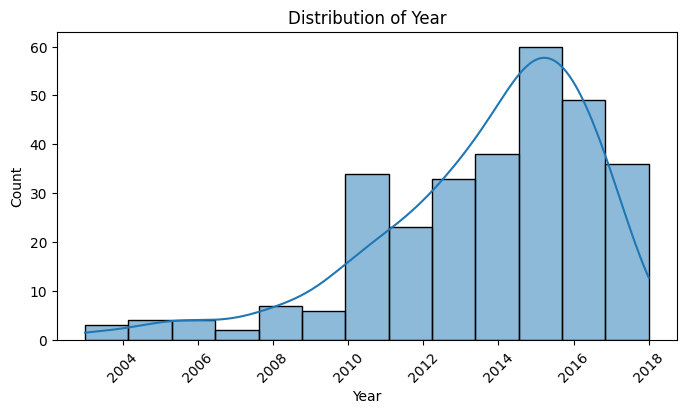

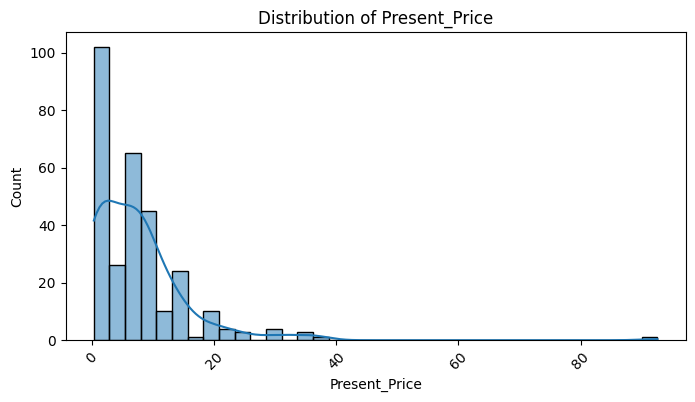

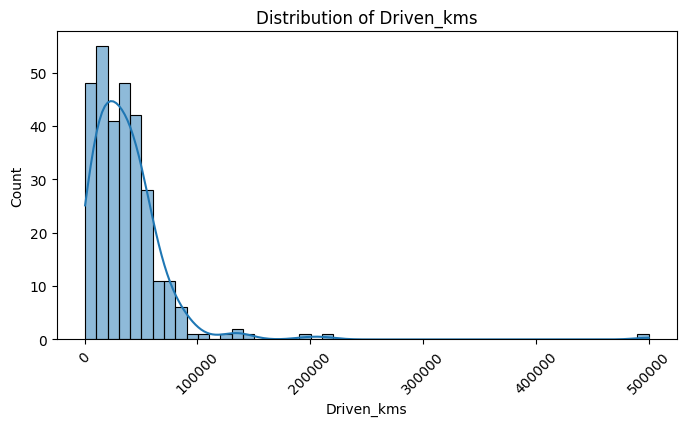

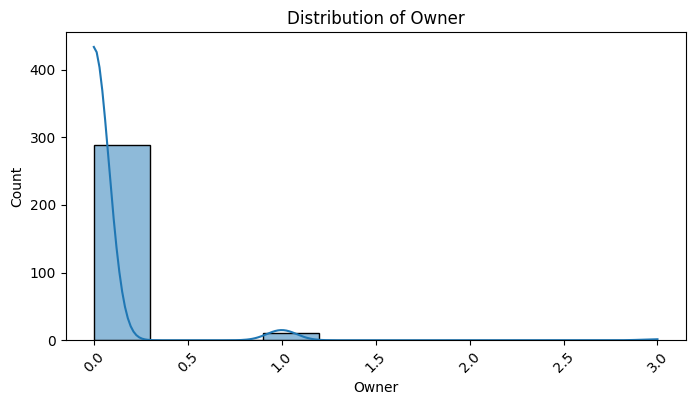

In [24]:
# =======================
# 8. plot numeric columns
# =======================

for cols in x.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8,4))
    sns.histplot(x[cols], kde=True)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {cols}')
    plt.show()

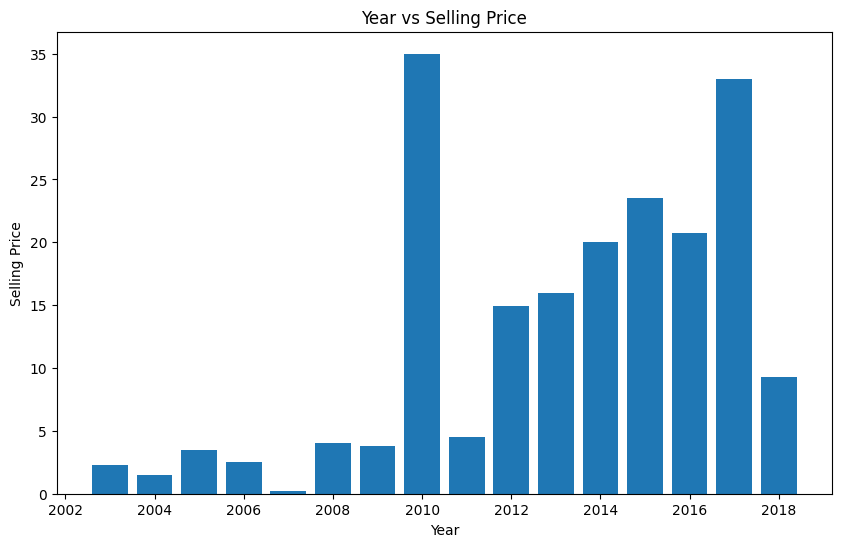

In [25]:
#=========================
# plot Year vs Selling_Price
#============================

plt.figure(figsize=(10,6))
plt.bar(df['Year'], df['Selling_Price'])
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Year vs Selling Price')
plt.show()


In [26]:
df.select_dtypes(include=["object"]).nunique()

Car_Name        98
Fuel_Type        3
Selling_type     2
Transmission     2
dtype: int64

In [27]:
df.select_dtypes(include=['int64','float64']).nunique()

Year              16
Selling_Price    156
Present_Price    148
Driven_kms       206
Owner              3
dtype: int64

In [28]:
# =======================
# 8. Define Features
# =======================

numeric_features = ["Car_Age", "Present_Price", "Driven_kms", "Owner"]
categorical_features = ["Brand", "Fuel_Type", "Selling_type", "Transmission"]
x = df_clean.drop('Selling_Price', axis=1)
y = df_clean['Selling_Price']

In [29]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=42))
])


In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', model)])
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }


In [32]:
# =======================
# 11. Model Training & Evaluation
# =======================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
}

# Store results
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),   # ✅ Add preprocessor here
                           ("regressor", model)])
    
    pipe.fit(x_train, y_train)
    preds = pipe.predict(x_test)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append([name, round(r2, 4), round(mae, 4), round(rmse, 4)])


               Model  R² Score     MAE    RMSE
0  Linear Regression    0.9448  0.6027  0.7678
1      Random Forest    0.9779  0.3313  0.4858
2  Gradient Boosting    0.9835  0.2914  0.4203


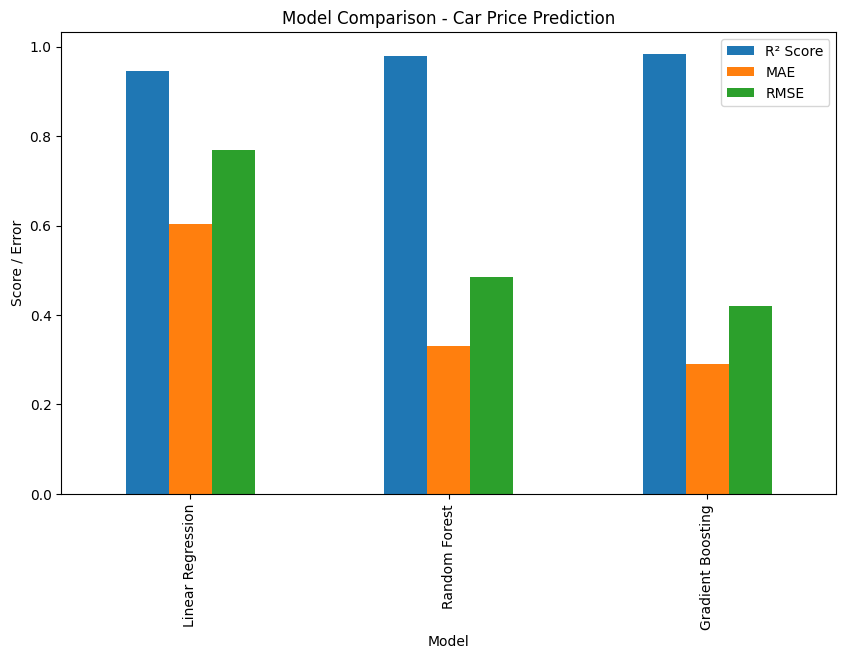

In [33]:
# =======================
# 12. Results Comparison
# =======================

results_df = pd.DataFrame(results, columns=["Model", "R² Score", "MAE", "RMSE"])
print(results_df)

# Bar Plot
results_df.set_index("Model")[["R² Score", "MAE", "RMSE"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison - Car Price Prediction")
plt.ylabel("Score / Error")
plt.show()


In [34]:
rf_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                          ('regressor', RandomForestRegressor(random_state=42))])

param_grid = {
    'regressor__n_estimators': [200],
    'regressor__max_depth': [None],
    'regressor__min_samples_split': [2]
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown catego

Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best Score: 0.9270917300242326


In [35]:

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 0.28660030948855436
RMSE: 0.41334702012598856


In [36]:
accuracy = r2_score(y_test, y_pred)
print("R² Score:", accuracy)

R² Score: 0.9840149420515227


In [37]:
import joblib 

In [38]:
joblib.dump(model, "car_price_model.pkl")
print("✅ Model saved as car_price_model.pkl")

✅ Model saved as car_price_model.pkl


In [42]:
!pip install -U ydata-profiling


from ydata_profiling import ProfileReport
profile = ProfileReport(df)
profile.to_notebook_iframe()


  Using cached pandas-2.3.3-cp313-cp313-macosx_10_13_x86_64.whl.metadata (91 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_10_13_x86_64.whl.metadata (2.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached typeguard-4.4.4-py3-none-any.whl.metadata (3.3 kB)
  Using cached dacite-1.9.2-py3-none-any.whl.metadata (17 kB)
  Using cached pillow-12.1.0-cp313-cp313-macosx_10_13_x86_64.whl.metadata (8.8 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_10_13_x86_64.whl.metadata (2.7 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_10_13_x86_64.whl.metadata (6.3 kB)
  Using cached python_dateutil-2.9.0.post0-py2.

ModuleNotFoundError: No module named 'ydata_profiling'